In [1]:
import os
import datetime

import icepacktools as ipt

In [5]:
# Load history output
ip_dirs_path = "/root/icepack-dirs"
run_dict = {
    "hocn_mushy_thermo": None,
    "hocn_mushy_thermo_apond_refactor": None,
    "hocn_mushy_thermo_formdrag": None,
    
            }
trcr_dict = {17: 'alvl',
             18: 'vlvl',
             19: 'apnd',
             20: 'hpnd',
             21: 'ipnd',
             }
trcrn_dict = {17: 'alvln',
              18: 'vlvln',
              19: 'apndn',
              20: 'hpndn',
              21: 'ipndn',
              }

hist_dict = {}
for key, value in run_dict.items():
    hist_dict[key] = ipt.load_icepack_hist(run_name=key, 
                                           icepack_dirs_path=ip_dirs_path, 
                                           hist_filename=value,
                                           compute_albedo_ai=True,
                                           trcr_dict=trcr_dict,
                                           trcrn_dict=trcrn_dict)

/root/code/icepack_postprocessing/icepacktools.py:118: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  datetimeindex = ds.indexes['time'].to_datetimeindex()
/root/code/icepack_postprocessing/icepacktools.py:118: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  datetimeindex = ds.indexes['time'].to_datetimeindex()
/root/code/icepack_postprocessing/icepacktools.py:118: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operat

In [3]:
# Check that the modified outputs match the consortium main
comp = "hocn_mushy_thermo_apond_refactor"
# Check whether or not dataarrays are identical
for ni in [1, 2, 3, 4]:
    print(ni)
    for key, da in hist_dict["hocn_mushy_thermo"].sel(ni=ni).data_vars.items():
        if not da.equals(hist_dict[comp].sel(ni=ni)[key]):
            print(key)
            print('max diff: ' + str((hist_dict[comp].sel(ni=ni)[key] - da).max().values))
            print('min diff: ' + str((hist_dict[comp].sel(ni=ni)[key] - da).min().values))
print("Above are data arrays that do not match.")

1
aice
max diff: 0.12547815794287287
min diff: -0.004505650790897708
vice
max diff: 0.004589657765836641
min diff: -0.0020813679332480906
vsno
max diff: 6.78150112262139e-05
min diff: -0.0005274206354205502
evap
max diff: 6.899484567723619e-07
min diff: -3.159565397964377e-07
frazil
max diff: 0.0033542024791392675
min diff: -0.0009701516205162242
fswabs
max diff: 8.44522674024806
min diff: -6.141928878305357
flwout
max diff: 1.9469514620952282
min diff: -33.04876004974108
fsens
max diff: 2.5496293686913285
min diff: -3.0110231195643795
fsurf
max diff: 9.34884788017714
min diff: -6.779442039389943
flat
max diff: 1.954551943742449
min diff: -0.9013720780012799
fcondtop
max diff: 0.3294350127543795
min diff: -6.77944203939022
meltt
max diff: 0.0003937261130260378
min diff: -0.0001623603384116769
meltb
max diff: 2.9730156594103517e-05
min diff: -1.9666427638418815e-06
meltl
max diff: 3.5046133432876567e-07
min diff: -2.8279426928239267e-07
snoice
max diff: 5.212116821646798e-05
min diff: -

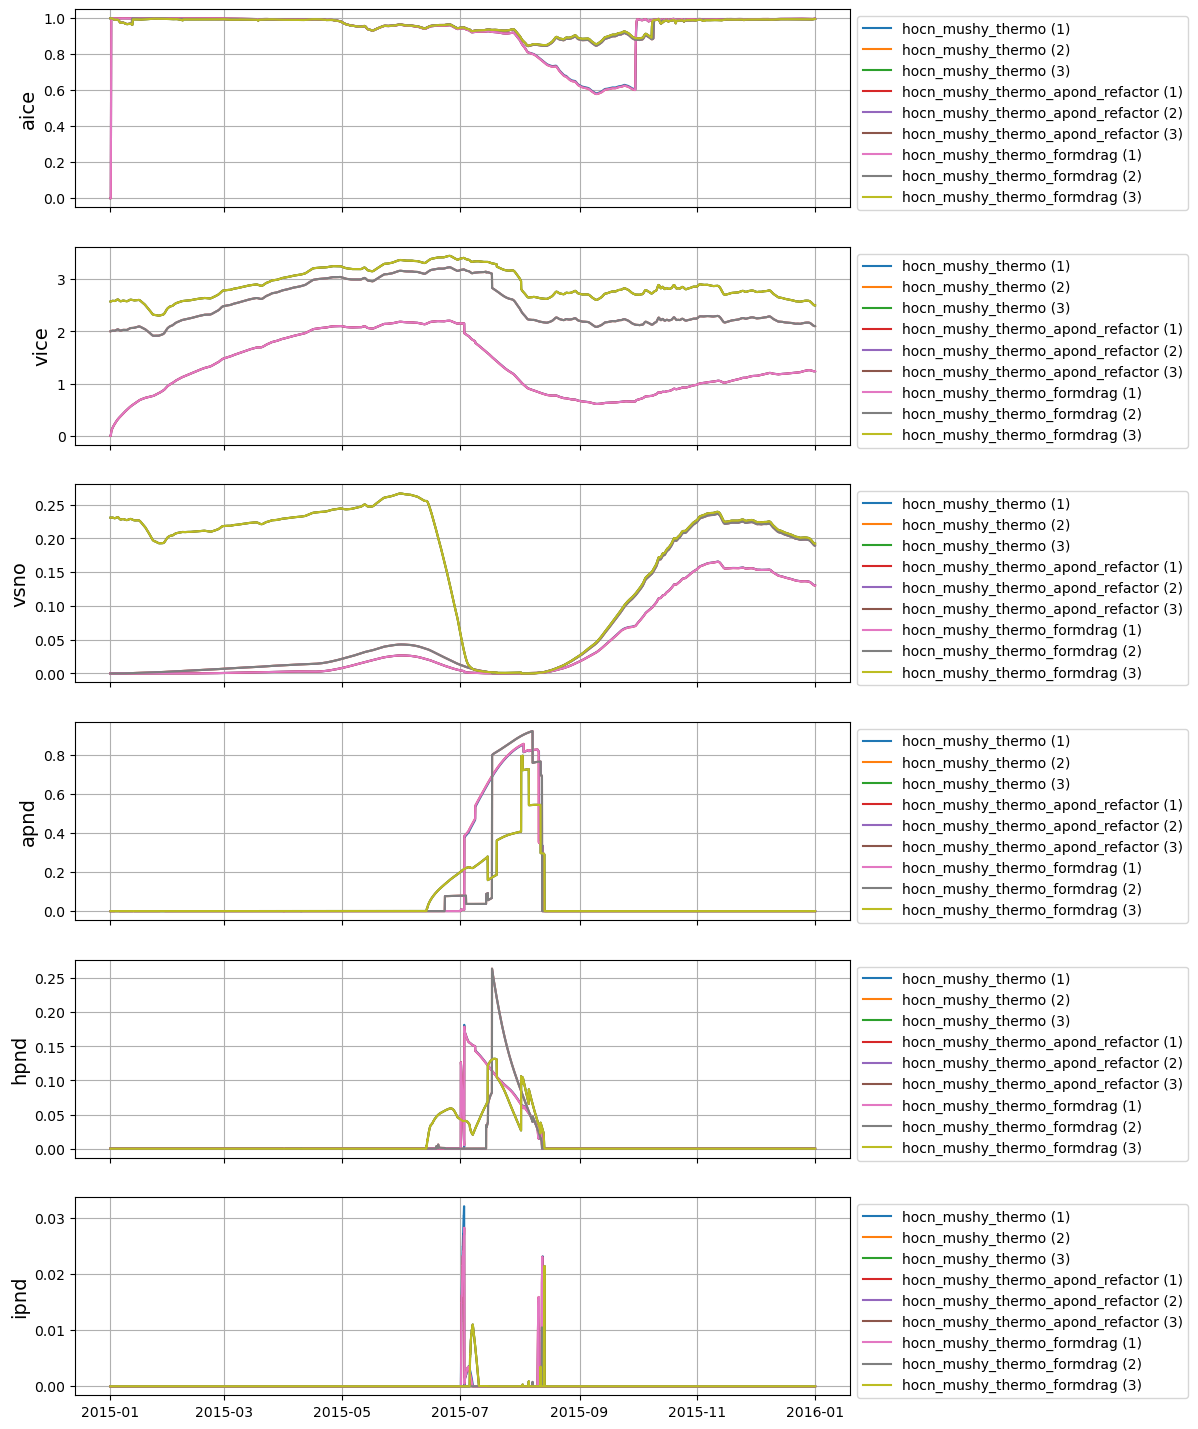

In [6]:
# Plot albedo diagnostics
run_plot_dict = {
                 "hocn_mushy_thermo": [1, 2, 3],
                 "hocn_mushy_thermo_apond_refactor": [1, 2, 3],
                 "hocn_mushy_thermo_formdrag": [1, 2, 3],
                 }
var_names = ['aice', 'vice', 'vsno', 'apnd', 'hpnd', 'ipnd']
xlim = [datetime.datetime.fromisoformat('2015-06-01'),
                  datetime.datetime.fromisoformat('2015-09-01')]

f, axs = ipt.plot_handler(run_plot_dict, var_names, hist_dict)#, xlim=xlim)